# Chapter 12: Credit for Consequences

The draft step earns no immediate reward. The review step produces the eventual benefit. If the controller learns only from immediate outcomes, it may never give preparation the credit it deserves. If it waits for every complete episode, it may learn slowly or fail to use partial traces.

This notebook puts three credit rules beside the same trajectory. Monte Carlo uses the discounted later return. TD(0) bootstraps from the next state's current value. Eligibility traces spread a later TD error backward through recently visited states. The changed case marks the end as truncation rather than true termination, exposing the value that can be lost when those two boundaries are confused.

**Outcome:** Compare Monte Carlo, TD(0), and accumulating TD(lambda) updates on one trajectory.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For a complete trajectory, the return target is G_t=r_t+gamma G_(t+1), with terminal continuation zero. For a truncated trace, this implementation initializes the final continuation from the supplied value estimate instead. The backward recurrence makes that distinction visible in every earlier target.

Monte Carlo updates V(s_t) by alpha[G_t-V(s_t)]. TD(0) uses delta_t=r_t+gamma V(s_(t+1))-V(s_t), replacing the next value with zero only at true terminal transition. Accumulating TD(lambda) first adds one to the current state's eligibility, updates every value by alpha delta_t e_t(s), then decays eligibility by gamma lambda.

All three rules receive the same reward sequence and initial values, but their online updates differ. A state revisited within the trace can accumulate eligibility or receive multiple updates. This notebook implements one sequential pass, not an asymptotic convergence experiment. Lambda controls how far a later error reaches backward; it does not manufacture missing future rewards.

How this relates to Equation (12.4). The chapter writes the forward view: each visited state moves toward its lambda-return. This notebook implements the backward view, accumulating eligibility traces applied online during one pass. For a terminal episode the two give identical updates when the updates are offline, meaning the value estimates are held fixed during the episode and the summed increments are applied at the end. With online updates, as here, they still agree exactly when no state repeats within the episode, because every update touches only states already visited and no later TD error reads them. When a state repeats, online updates change estimates that later errors use, and the result can differ from the Equation (12.4) update. The default trajectory has no repeated state, so its values 0.4 and 0.5 equal the forward-view updates.

## Apply this to an agent

A release outcome may arrive after drafting and review. Follow how that late consequence changes earlier state values. Mark whether the trace truly ended or was merely cut off; otherwise an assumed continuation can be mistaken for evidence.

## A calculation you can run

Give the ordered state list, rewards, initial values, discount, learning rate, lambda, and exact terminal flag. The state list must have one more element than the reward list. Values must exist for every named state. The code computes backward return targets, then applies each update rule to its own independent copy of the initial value map.

The return plot shows the target associated with each transition, while the trace-error plot shows the online TD errors used by eligibility updates. Consult the three final value maps to compare credit assignment. In the changed case the final state's estimate is 2 and terminal is false. Predict how that bootstrap changes the targets before running the calculation.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 12
inputs = {'states': ['draft', 'review', 'done'],
 'rewards': [0, 1],
 'discount': 1,
 'learning_rate': 0.5,
 'lambda': 0.8,
 'terminal': True,
 'values': {'draft': 0, 'review': 0, 'done': 0}}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed teaching example

Calculated quantities:
{
  "returns": [
    1.0,
    1.0
  ],
  "monte_carlo_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.5
  },
  "td_zero_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.0
  },
  "td_lambda_values": {
    "review": 0.5,
    "done": 0.0,
    "draft": 0.4
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: completed locally; cons

Default returns are [1,1]. With alpha=0.5, Monte Carlo assigns draft and review values 0.5. TD(0) updates draft from a zero next value, leaving it at zero, then assigns review 0.5. TD(lambda) carries the later error back with eligibility 0.8, giving draft 0.4 and review 0.5.

In the changed truncated case, final bootstrap is 2. Returns become [3,3]. Treating that trace as terminal would incorrectly erase the supplied continuation estimate. Whether 2 is a good estimate is a separate question; the credit arithmetic simply makes its dependence explicit.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


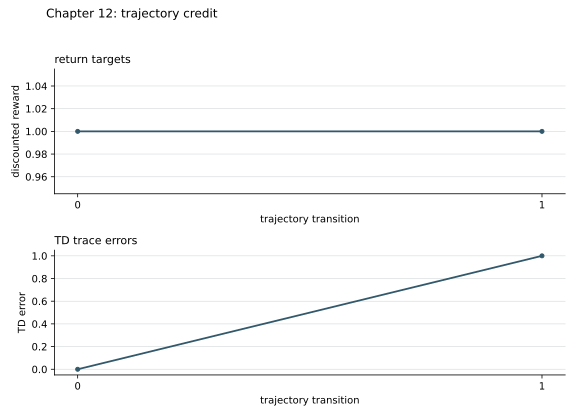

In [3]:
display(SVG(figure_svg(report)))

**Figure 12.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Bootstrapping can propagate a bad value estimate. Monte Carlo avoids that particular dependence in complete episodes, but it depends on the observed later return and can have high sampling variability. Neither target dominates in every setting.

The terminal flag is especially important in limited-budget logs. An observation window ending is not proof that the underlying task terminated. Setting terminal true after a timeout can systematically suppress continuation value. Setting it false at actual termination can add imaginary future reward.

Trace conventions also matter. Replacing traces and accumulating traces are different algorithms when states repeat. This implementation uses accumulating traces. Compare it with equations under that convention, and avoid claiming convergence from one pass over a short supplied trajectory. Learning-rate schedules, visitation, and process assumptions would need their own study.

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "returns": [
    3.0,
    3.0
  ],
  "monte_carlo_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 1.5
  },
  "td_zero_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 0.0
  },
  "td_lambda_values": {
    "review": 1.5,
    "done": 2.0,
    "draft": 1.2
  },
  "bootstrap_value": 2.0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: completed l

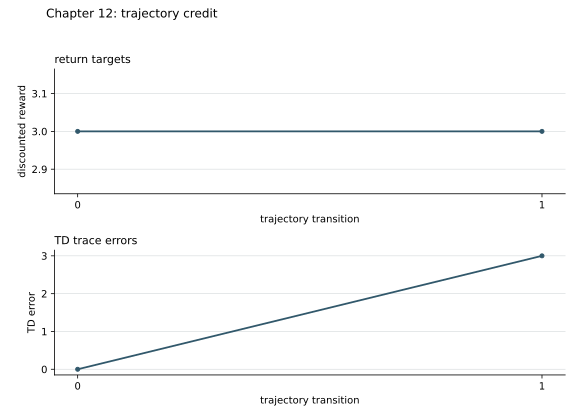

In [4]:
changed_inputs = {'states': ['draft', 'review', 'done'],
 'rewards': [0, 1],
 'discount': 1,
 'learning_rate': 0.5,
 'lambda': 0.8,
 'terminal': False,
 'values': {'draft': 0, 'review': 0, 'done': 2}}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 12.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case sets lambda to zero. Accumulating TD(lambda) then updates only the currently eligible state before immediate decay, so its final values should agree with TD(0) under the same sequential convention. This is an independent structural check rather than a visual similarity claim.

To apply this to your own system, preserve reward timing and state identity, and mark whether the final boundary is real termination or missing observation. If the final value is a fitted estimate, record its provenance. A trajectory-credit report should show targets and bootstrap assumptions as well as updated values, so a surprising change can be traced to evidence rather than hidden continuation.

In [5]:
transfer_inputs = {'states': ['a', 'b', 'c', 'd'],
 'rewards': [1, 0, 2],
 'discount': 0.9,
 'learning_rate': 0.2,
 'lambda': 0,
 'terminal': True,
 'values': {'a': 0, 'b': 1, 'c': 0, 'd': 0}}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: constructed transfer example

Calculated quantities:
{
  "returns": [
    2.62,
    1.8,
    2.0
  ],
  "monte_carlo_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.524,
    "b": 1.16
  },
  "td_zero_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "td_lambda_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on current estimates.

Execution: co

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **states:** Trajectory state identifiers, one more than reward count.
- **rewards:** Finite observed immediate rewards.
- **discount:** Gamma in [0,1].
- **learning_rate:** Step size in [0,1].
- **lambda:** Trace decay parameter in [0,1].
- **terminal:** Exact boolean distinguishing true termination from truncation.
- **values:** Initial finite value for every trajectory state.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch12.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 12: trajectory-credit
How should a late consequence change values assigned to earlier states?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "returns": [
    2.62,
    1.8,
    2.0
  ],
  "monte_carlo_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.524,
    "b": 1.16
  },
  "td_zero_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "td_lambda_values": {
    "d": 0.0,
    "c": 0.4,
    "a": 0.38,
    "b": 0.8
  },
  "bootstrap_value": 0
}

Interpretation:
All three estimators see the same rewards. A truncated trajectory retains its supplied final bootstrap value; a terminal trajectory sets that continuation to zero.

Assumptions:
- One sequential pass with accumulating eligibility traces.
- Initial values, discount, step size, and terminal status are declared.

Limitations:
- This finite update does not demonstrate convergence.
- Bootstrapping trades dependence on later observations for dependence on c

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c12-d01"></a>

### Demonstration 1: One run, three update rules, pass by pass

When a run pays only at its last step, which state estimates move, and how far does the news travel on each pass under each rule?

![Equation 12.1](../assets/math/d6697e3cc821de210964.svg)

![Equation 12.2](../assets/math/cc2c6da6e8a537b237b5.svg)

![Equation 12.3](../assets/math/bea157a42325799a5a1c.svg)

**Symbols and units:** V-hat is the current estimate of a state's future return. Ret is the return that actually followed the state. alpha is the step size, the fraction of the gap that is kept. r is the immediate reward, gamma is the discount factor (1 except in the a, b, c, d run, where it is 0.9), x_t is the state visited at step t, and delta is the one-step error: the reward plus the next state's estimate minus the state's own estimate. The end of a terminated run has value 0; a truncated run keeps a supplied estimate. The trace rule uses lambda to carry later errors back to earlier states. A pass is one sequential run through the same trajectory.

The outcome rule waits for the end and then moves every visited estimate toward the return that followed it. The one-step rule uses the reward plus the next estimate as its target. With every estimate at 0.5 and zero reward before the last step, the first three errors are exactly zero, so only the last state moves on the first pass; on later passes the raised estimate reaches one state further back each time. The trace rule sits between the two. In the truncated run the final estimate is supplied, so it anchors the targets instead of the terminal value 0.

**Use in this chapter:** When a long run ends in success or failure, an update that touches every visited state is a statement about the returns that followed those states under the policy that was run. It is not an itemised receipt for each action, and the one-step rule's zero errors do not say the early steps were unimportant.

**Assumptions:** States visited once each in a fixed order, one sequential pass repeated on the same trajectory, and values and step sizes declared for each run (the notebook's draft, review, done run, its truncated variant and its a, b, c, d run, and the book's four-action run). Different starting estimates, discounts or replay orders change which states move. Repeating one trajectory is a teaching device, not a training set.

**Predict before running:** In the four-action run (step size 0.1, estimates 0.5, final reward 1), after the first pass, how many of the four estimates have moved under the outcome rule, and how many under the one-step rule?

**Controls you can change:**

- **Run:** `case` accepts 'book', 'default', 'changed', 'transfer'.
- **Passes through the run:** `passes_done` accepts 1, 2, 3.

**Source section:** The two rules on one trajectory.

**Evidence:** constructed teaching example.

Constructed example: the book's four-action trajectory (estimates 0.5, step size 0.1, final reward 1) and the laboratory's default, changed and transfer cases (draft, review, done; truncated; a, b, c, d), computed with the laboratory's trajectory-credit function and repeated pass by pass.

Prediction choices:

1. Only state 4 under both rules.
2. All four under the outcome rule, only state 4 under the one-step rule.
3. Only state 4 under the outcome rule, all four under the one-step rule.
4. All four under both rules.

**Boundary of the conclusion:** The convergence result is for the linear one-step rule with linearly independent state representations under repeated presentation, and arbitrary language-model agent representations and training procedures need not satisfy those conditions.

**Common wrong turn:** The chapter says the four identical updates of the outcome rule are predictions of subsequent return, not allocations of causal responsibility, and that the first three TD errors vanish by arithmetic without certifying that those transitions were unimportant.

One run, three update rules, pass by pass
Controls: {"case": "book", "passes_done": 1}
Evidence: constructed teaching example

Calculated quantities:
Outcome rule, states in order: 0.550, 0.550, 0.550, 0.550
One-step rule, states in order: 0.500, 0.500, 0.500, 0.550
States moved (outcome / one-step): 4 / 1

Worked steps:
1. Outcome rule, state 1: return 1, 0.5 + 0.1 x (1 - 0.5) = 0.55.
2. Outcome rule, state 2: return 1, 0.5 + 0.1 x (1 - 0.5) = 0.55.
3. Outcome rule, state 3: return 1, 0.5 + 0.1 x (1 - 0.5) = 0.55.
4. Outcome rule, state 4: return 1, 0.5 + 0.1 x (1 - 0.5) = 0.55.
5. One-step rule, state 1: delta = 0 + 1 x 0.5 - 0.5 = 0, so 0.5 + 0.1 x 0 = 0.5.
6. One-step rule, state 2: delta = 0 + 1 x 0.5 - 0.5 = 0, so 0.5 + 0.1 x 0 = 0.5.
7. One-step rule, state 3: delta = 0 + 1 x 0.5 - 0.5 = 0, so 0.5 + 0.1 x 0 = 0.5.
8. One-step rule, state 4: delta = 1 + 1 x 0 - 0.5 = 0.5, so 0.5 + 0.1 x 0.5 = 0.55.

Pass 1 of the four-action run. Outcome rule: state 1: return 1, 0.5 + 0.1 x (1 - 

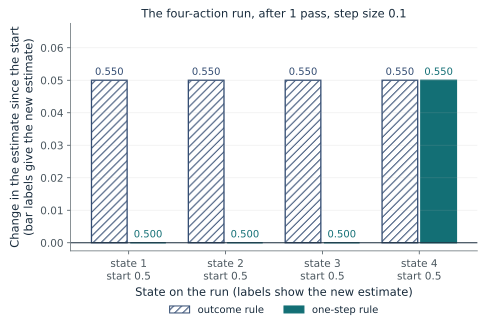

In [8]:
demo_id = 'C12-D01'
demo_controls = {'case': 'book', 'passes_done': 1}
demo_result = run_demo(12, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Run** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

One run, three update rules, pass by pass
Controls: {"case": "default", "passes_done": 1}
Evidence: constructed teaching example

Calculated quantities:
Outcome rule, states in order: 0.500, 0.500
One-step rule, states in order: 0.000, 0.500
Trace rule (lambda 0.8), states in order: 0.400, 0.500
States moved (outcome / one-step): 2 / 1

Worked steps:
1. Outcome rule, draft: return 1, 0 + 0.5 x (1 - 0) = 0.5.
2. Outcome rule, review: return 1, 0 + 0.5 x (1 - 0) = 0.5.
3. One-step rule, draft: delta = 0 + 1 x 0 - 0 = 0, so 0 + 0.5 x 0 = 0.
4. One-step rule, review: delta = 1 + 1 x 0 - 0 = 1, so 0 + 0.5 x 1 = 0.5.
5. Trace rule, step 1: error = 0 + 1 x 0 - 0 = 0; draft 0 + 0.5 x 0 x 1 = 0.
6. Trace rule, step 2: error = 1 + 1 x 0 - 0 = 1; draft 0 + 0.5 x 1 x 0.8 = 0.4; review 0 + 0.5 x 1 x 1 = 0.5.

Pass 1 of the draft, review, done run. Outcome rule: draft: return 1, 0 + 0.5 x (1 - 0) = 0.5. One-step rule: draft: delta = 0 + 1 x 0 - 0 = 0, so 0 + 0.5 x 0 = 0; review: delta = 1 + 1 x 0 - 

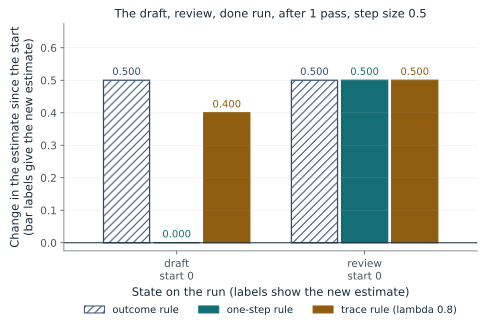

In [9]:
changed_controls = {'case': 'default', 'passes_done': 1}
changed_demo = run_demo(12, 'C12-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(12, 'C12-D01'):
    state = run_demo(12, 'C12-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "book",
      "passes_done": 1
    },
    "metrics": [
      [
        "Outcome rule, states in order",
        "0.550, 0.550, 0.550, 0.550"
      ],
      [
        "One-step rule, states in order",
        "0.500, 0.500, 0.500, 0.550"
      ],
      [
        "States moved (outcome / one-step)",
        "4 / 1"
      ]
    ]
  },
  {
    "controls": {
      "case": "book",
      "passes_done": 2
    },
    "metrics": [
      [
        "Outcome rule, states in order",
        "0.595, 0.595, 0.595, 0.595"
      ],
      [
        "One-step rule, states in order",
        "0.500, 0.500, 0.505, 0.595"
      ],
      [
        "States moved (outcome / one-step)",
        "4 / 2"
      ]
    ]
  },
  {
    "controls": {
      "case": "book",
      "passes_done": 3
    },
    "metrics": [
      [
        "Outcome rule, states in order",
        "0.636, 0.636, 0.636, 0.636"
      ],
      [
        "One-step rule, states in order",
        "0.500, 0.5005

**Check your understanding:** In the draft, review, done run (step size 0.5, lambda 0.8, terminal) after one pass, what does the outcome rule give draft, and what does the one-step rule give draft?

[Answer and worked reasoning](../solutions/ch12.md#demonstration-1). [Matching browser demonstration](../readers/12-trajectory-credit/reader.html#C12-D01).

<a id="demo-c12-d02"></a>

### Demonstration 2: Eight episodes, two answers about state A

Why do the two rules agree about state B but disagree about state A, which was seen only once?

![Equation 12.1](../assets/math/d6697e3cc821de210964.svg)

![Equation 12.2](../assets/math/cc2c6da6e8a537b237b5.svg)

![Equation 12.3](../assets/math/bea157a42325799a5a1c.svg)

**Symbols and units:** A and B are the two states. Each episode ends with a reward when it reaches the end. The outcome rule sets a state to the average return that followed its visits. The one-step rule sets a state to the reward plus the estimate of the state that followed it. No discounting (gamma is 1). x_t is the state at step t and V-hat its estimate. Values are what each rule settles on when it is run in batch form, repeatedly over the same eight episodes with a small step size.

B is visited eight times, so both rules average its eight returns. A is visited once, followed by B with no reward. The outcome rule copies that single return. The one-step rule says A is worth whatever B is worth, and so it borrows the evidence from the seven episodes that never contained A.

**Use in this chapter:** When a state is rare but its successor is common, ask whether the stated process really sends the rare state to that successor. If so, the successor-based answer pools more evidence; if not, it imports a mistake.

**Assumptions:** The process is stipulated: A always goes to B with no reward, and B pays at random. Eight observations do not prove that. The one-step answer is better only if that process is real and the successor's value is reliable. The outcome rule is not wrong about the data; it fits them exactly.

**Predict before running:** With six of the seven B-only episodes paying 1 and the A episode ending at 0, what does each rule say A is worth?

**Controls you can change:**

- **B-only episodes that pay 1 (out of 7):** `ones_in_b_only` accepts 3, 6, 7.
- **Reward at the end of the one A episode:** `a_final` accepts 0, 1.

**Source section:** Eight episodes, two answers.

**Evidence:** constructed teaching example.

Constructed example: the book's eight-episode construction (six ones among the seven B-only episodes, the A episode ending at 0), with those counts varied.

Prediction choices:

1. Outcome rule 0.75, one-step rule 0.
2. Both rules say 0.75.
3. Both rules say 0.
4. Outcome rule 0, one-step rule 0.75.

**Common wrong turn:** The chapter says the outcome rule is not wrong about the data: it fits the single A episode with zero error, which is exactly what its guarantee promises. The guarantee names a criterion, fit to a sample, and what anybody wanted is accuracy on cases not yet seen.

Eight episodes, two answers about state A
Controls: {"ones_in_b_only": 6, "a_final": 0}
Evidence: constructed teaching example

Calculated quantities:
Value of B (both rules): 0.750
Value of A, outcome rule: 0.000
Value of A, one-step rule: 0.750
Disagreement about A: 0.750

Worked steps:
1. B is visited 8 times; its returns hold 6 + 0 ones, so B = (6 + 0) / 8 = 0.750.
2. A is visited once and the return that followed was 0, so the outcome rule sets A = 0.
3. Every A transition goes to B with reward 0, so the one-step rule sets A = 0 + B = 0.750.
4. Disagreement = |0.750 - 0.000| = 0.750.

B's returns are 6 + 0 ones in 8 visits, so B = (6 + 0) / 8 = 0.750 under either rule. The outcome rule gives A the one return it saw: 0. The one-step rule gives A = 0 + B = 0.750. Disagreement about A = |0.750 - 0.000| = 0.750. The outcome rule fits the single A episode exactly (error 0) but is 0.750 away from B's value; the one-step rule gives A the value of its successor B, using the seven episodes

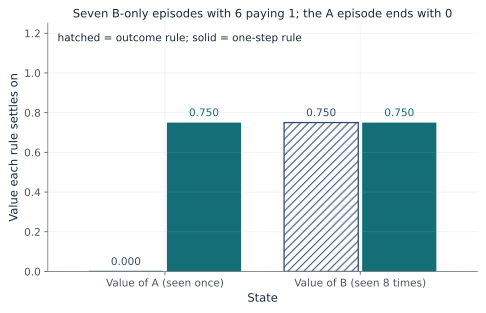

In [11]:
demo_id = 'C12-D02'
demo_controls = {'ones_in_b_only': 6, 'a_final': 0}
demo_result = run_demo(12, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **B-only episodes that pay 1 (out of 7)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Eight episodes, two answers about state A
Controls: {"ones_in_b_only": 3, "a_final": 0}
Evidence: constructed teaching example

Calculated quantities:
Value of B (both rules): 0.375
Value of A, outcome rule: 0.000
Value of A, one-step rule: 0.375
Disagreement about A: 0.375

Worked steps:
1. B is visited 8 times; its returns hold 3 + 0 ones, so B = (3 + 0) / 8 = 0.375.
2. A is visited once and the return that followed was 0, so the outcome rule sets A = 0.
3. Every A transition goes to B with reward 0, so the one-step rule sets A = 0 + B = 0.375.
4. Disagreement = |0.375 - 0.000| = 0.375.

B's returns are 3 + 0 ones in 8 visits, so B = (3 + 0) / 8 = 0.375 under either rule. The outcome rule gives A the one return it saw: 0. The one-step rule gives A = 0 + B = 0.375. Disagreement about A = |0.375 - 0.000| = 0.375. The outcome rule fits the single A episode exactly (error 0) but is 0.375 away from B's value; the one-step rule gives A the value of its successor B, using the seven episodes

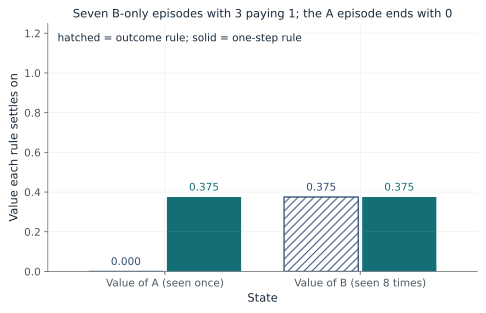

In [12]:
changed_controls = {'ones_in_b_only': 3, 'a_final': 0}
changed_demo = run_demo(12, 'C12-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(12, 'C12-D02'):
    state = run_demo(12, 'C12-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "ones_in_b_only": 3,
      "a_final": 0
    },
    "metrics": [
      [
        "Value of B (both rules)",
        "0.375"
      ],
      [
        "Value of A, outcome rule",
        "0.000"
      ],
      [
        "Value of A, one-step rule",
        "0.375"
      ],
      [
        "Disagreement about A",
        "0.375"
      ]
    ]
  },
  {
    "controls": {
      "ones_in_b_only": 3,
      "a_final": 1
    },
    "metrics": [
      [
        "Value of B (both rules)",
        "0.500"
      ],
      [
        "Value of A, outcome rule",
        "1.000"
      ],
      [
        "Value of A, one-step rule",
        "0.500"
      ],
      [
        "Disagreement about A",
        "0.500"
      ]
    ]
  },
  {
    "controls": {
      "ones_in_b_only": 6,
      "a_final": 0
    },
    "metrics": [
      [
        "Value of B (both rules)",
        "0.750"
      ],
      [
        "Value of A, outcome rule",
        "0.000"
      ],
      [
        "Valu

**Check your understanding:** Suppose three of the seven B-only episodes pay 1 and the A episode ends at 0. What is B, and how far is the outcome rule's value for A from the one-step rule's?

[Answer and worked reasoning](../solutions/ch12.md#demonstration-2). [Matching browser demonstration](../readers/12-trajectory-credit/reader.html#C12-D02).

<a id="demo-c12-d03"></a>

### Demonstration 3: One dial between the two rules

How does the blending parameter lambda divide weight between short lookahead targets and the complete return, and what does it do to prediction on a random walk?

![Equation 12.4](../assets/math/3def44a4bcac72579801.svg)

**Symbols and units:** lambda is the blending parameter between 0 and 1. A k-step target adds the next k rewards to the estimate k steps ahead. N is the number of transitions in the whole episode and t the current step, so n = N - t is the number of transitions left (8 here, as in Figure 12.4); j counts the rewards inside a target, and gamma is the discount factor (the weights do not depend on it). With n transitions left, the first n - 1 targets get weight (1 - lambda) x lambda^(k-1) and the complete return gets the remaining weight, lambda^(n-1). The weights always add to 1. It is not the step size and not the discount factor. In the right panel, the true value of each interior state B to F of the seven-state random walk is k/6 for k = 1 to 5, and the error is the root mean square miss over those five states.

Each extra step of lookahead is weighted lambda times the one before it, so small lambda piles weight on the one-step target and large lambda spreads it out. Whatever weight the lookahead targets leave over goes to the complete return, so the two opening rules are the two ends of the dial. The right panel scores the dial on the chapter's random walk. When each training set is presented repeatedly, the outcome rule (lambda 1) has the lowest error on the training sample and the highest error against the truth. Presented once, the best lambda is small but is not clearly the one-step end, and the chapter attributes that to the one-step rule being slow at propagating information back.

**Use in this chapter:** When a method is described as temporal-difference (TD) learning with a lambda setting, read it as a choice of target mixture: how much to trust the agent's own estimates relative to what actually happened. For a fixed policy and a prediction target, it changes the estimator, not the objective.

**Assumptions:** The weights are for a single episode that terminates after n transitions, with terminal value zero. The right panel is a constructed experiment: 100 training sets of 10 walks drawn with a fixed seed, a table of five values, and, for the single presentation, a step size chosen from a grid at each lambda. It reproduces the shape of the chapter's experiment, not Sutton's published numbers, and it does not say which lambda is best for any other problem.

**Predict before running:** With 8 transitions remaining and lambda = 0.9, does the complete return or the one-step target get more weight?

**Controls you can change:**

- **Blending parameter lambda:** `lam` accepts 0, 0.3, 0.9, 1.
- **How each training set is presented:** `protocol` accepts 'repeated', 'once'.

**Source section:** The family between the two rules.

**Evidence:** constructed teaching example.

Constructed example: the weights of Equation (12.4) for the book's eight-transition case (Figure 12.4) and the chapter's random-walk chain (Figure 12.2), with seeded walks and lambda values defined for this reader.

Prediction choices:

1. The one-step target, which always gets the most weight.
2. They get equal weight.
3. The complete return, 0.9^7 = 0.478, against 0.1 for the one-step target.

**Boundary of the conclusion:** The random walk is five numbers; the results are a demonstration rather than a general performance claim.

**Common wrong turn:** The chapter says lambda is a statement about the estimator, how much the agent trusts its own estimates relative to what happened, while the discount factor is a statement about the objective. It is also not the step size, which controls how far each update moves, and not exploration.

One dial between the two rules
Controls: {"lam": 0.9, "protocol": "repeated"}
Evidence: constructed teaching example

Calculated quantities:
Weight on the one-step target: 0.1000
Weight on the full return: 0.4783
Weight on the other lookahead targets: 0.4217
Weights add to: 1.0000
Random-walk error at this lambda: 0.145
Random-walk error at lambda 0 and 1: 0.130 and 0.173
Training-sample error at lambda 0 and 1: 0.427 and 0.407

Worked steps:
1. First weight = 1 - lambda = 1 - 0.9 = 0.1000.
2. Weight of the k-step target = (1 - lambda) x lambda^(k-1), for k = 1 to 7.
3. Full-return weight = lambda^7 = 0.9^7 = 0.4783.
4. Lookahead weights add to 1 - 0.4783 = 0.5217.
5. Total = 0.5217 + 0.4783 = 1.0000.

First weight = 1 - 0.9 = 0.1000. Full-return weight = 0.9^7 = 0.4783. Check: lookahead weights add to 1 - 0.9^7 = 0.5217, and 0.5217 + 0.4783 = 1.0000. Raising lambda moves weight from the short targets toward the complete return, but the weights always add to one. In the constructed ran

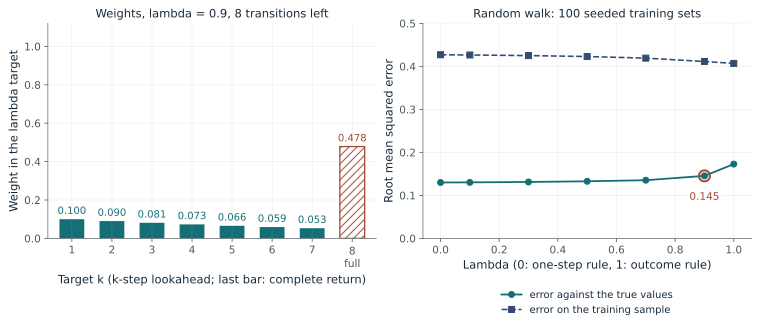

In [14]:
demo_id = 'C12-D03'
demo_controls = {'lam': 0.9, 'protocol': 'repeated'}
demo_result = run_demo(12, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Blending parameter lambda** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

One dial between the two rules
Controls: {"lam": 0, "protocol": "repeated"}
Evidence: constructed teaching example

Calculated quantities:
Weight on the one-step target: 1.0000
Weight on the full return: 0.0000
Weight on the other lookahead targets: 0.0000
Weights add to: 1.0000
Random-walk error at this lambda: 0.130
Random-walk error at lambda 0 and 1: 0.130 and 0.173
Training-sample error at lambda 0 and 1: 0.427 and 0.407

Worked steps:
1. First weight = 1 - lambda = 1 - 0.0 = 1.0000.
2. Weight of the k-step target = (1 - lambda) x lambda^(k-1), for k = 1 to 7.
3. Full-return weight = lambda^7 = 0.0^7 = 0.0000.
4. Lookahead weights add to 1 - 0.0000 = 1.0000.
5. Total = 1.0000 + 0.0000 = 1.0000.

First weight = 1 - 0.0 = 1.0000. Full-return weight = 0.0^7 = 0.0000. Check: lookahead weights add to 1 - 0.0^7 = 1.0000, and 1.0000 + 0.0000 = 1.0000. At lambda = 0 all weight sits on the one-step target, which is the target inside Equation (12.2). In the constructed random walk, each of 

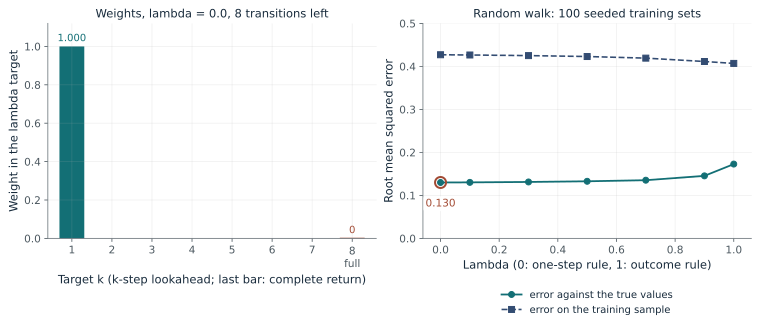

In [15]:
changed_controls = {'lam': 0, 'protocol': 'repeated'}
changed_demo = run_demo(12, 'C12-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(12, 'C12-D03'):
    state = run_demo(12, 'C12-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "lam": 0,
      "protocol": "repeated"
    },
    "metrics": [
      [
        "Weight on the one-step target",
        "1.0000"
      ],
      [
        "Weight on the full return",
        "0.0000"
      ],
      [
        "Weight on the other lookahead targets",
        "0.0000"
      ],
      [
        "Weights add to",
        "1.0000"
      ],
      [
        "Random-walk error at this lambda",
        "0.130"
      ],
      [
        "Random-walk error at lambda 0 and 1",
        "0.130 and 0.173"
      ],
      [
        "Training-sample error at lambda 0 and 1",
        "0.427 and 0.407"
      ]
    ]
  },
  {
    "controls": {
      "lam": 0,
      "protocol": "once"
    },
    "metrics": [
      [
        "Weight on the one-step target",
        "1.0000"
      ],
      [
        "Weight on the full return",
        "0.0000"
      ],
      [
        "Weight on the other lookahead targets",
        "0.0000"
      ],
      [
        "Weights add to

**Check your understanding:** With 8 transitions remaining and lambda = 0.3, what weight does the first target get, and what does the complete return get?

[Answer and worked reasoning](../solutions/ch12.md#demonstration-3). [Matching browser demonstration](../readers/12-trajectory-credit/reader.html#C12-D03).

<a id="demo-c12-d04"></a>

### Demonstration 4: A positive error for a useless search, and a value that switches the action

Can the one-step error be positive after a search that cost something and returned nothing useful, and when does an updated value change the next action?

![Equation 12.2](../assets/math/cc2c6da6e8a537b237b5.svg)

![Equation 12.3](../assets/math/bea157a42325799a5a1c.svg)

**Symbols and units:** r is the reward for the call, here a cost of 0.02 (reward -0.02). The discount factor gamma is 1. The prior estimate is the agent's forecast of future return before the search (0.20); the successor estimate is its forecast after the search. delta is the reward plus the successor estimate minus the prior estimate; it is the temporal-difference (TD) error. Right panel: at state x, finish ends with reward 0.6, and inspect costs 0.1 and reaches state y, where a fixed continuation policy takes the final action. The estimate of y starts at 0.5 and is trained with step size alpha on a run that reaches y and pays 1.

The error compares the old forecast with the observed reward plus the new forecast. A cost of 0.02 makes the reward slightly negative, but the sign is set by the two estimates. The right panel adds the bridge to action: training moves the continuation estimate of y from 0.5 toward 1, so inspect rises from 0.4 to -0.1 plus the new estimate, and it overtakes finish (0.6) once that estimate passes 0.7, which with these numbers needs a step size above 0.4. The update needed visits to y; a controller that always finishes never reaches y.

**Use in this chapter:** When reading a log of TD errors from an agent, do not treat a positive error as praise for the call just made, or a negative one as blame. Credit for a particular call needs a comparison with what would have happened without it, which these updates do not provide.

**Assumptions:** One transition with the reward and estimates set by hand, as in the chapter's example, and a model at x that is known while the continuation value is learned. Estimates here are declared numbers, not fitted values; one reward of 1 may overstate the continuation policy's mean, so the switch is an improvement in the estimated comparison, and its real return still needs evaluation.

**Predict before running:** With the prior estimate at 0.20, which successor estimates give a positive error: 0.10, 0.50 or 0.80?

**Controls you can change:**

- **Estimate after the search:** `successor` accepts 0.1, 0.5, 0.8.
- **Step size for training the estimate of y:** `alpha` accepts 0.3, 0.4, 0.5, 0.8.

**Source section:** When a learned value changes the next action.

**Evidence:** constructed teaching example.

Constructed example: the book's first search (reward -0.02, estimates 0.20 before and 0.50 or 0.10 after) and its finish-or-inspect example (finish 0.6, inspect cost 0.1, estimate 0.5, step size 0.8); other successor estimates and step sizes are defined for this reader; both updates are checked against the laboratory's trajectory-credit function.

Prediction choices:

1. All three, because the cost is only 0.02.
2. 0.50 and 0.80: any successor above 0.22.
3. Only 0.80.

**Boundary of the conclusion:** Chapter 14 takes up what happens when the dynamics are learned explicitly rather than implied.

**Common wrong turn:** The chapter says the TD error is not a verdict on the call: with a reward of -0.02, a prior estimate of 0.20 and a successor estimate of 0.50 the error is 0.28, positive despite the search's cost and lack of useful results, and an optimistic estimate can fall after a useful action.

A positive error for a useless search, and a value that switches the action
Controls: {"successor": 0.5, "alpha": 0.8}
Evidence: constructed teaching example

Calculated quantities:
TD error delta: 0.28
Sign: positive
Successor estimate that gives zero: 0.22
Continuation estimate after training: 0.900
Inspect after training: 0.800
Action chosen after training: inspect

Worked steps:
1. Search error: delta = (-0.02) + 0.50 - 0.20 = 0.28 (positive).
2. Zero error at a successor estimate of 0.20 + 0.02 = 0.22.
3. Before training: inspect = (-0.1) + 0.5 = 0.4 against finish 0.6, so finish.
4. Training run reaches y and pays 1: delta = 1 + 0 - 0.5 = 0.5.
5. Update: 0.5 + 0.8 x 0.5 = 0.900.
6. After training: inspect = (-0.1) + 0.900 = 0.800 against finish 0.6: inspect.

delta = (-0.02) + 0.50 - 0.20 = 0.28. The error is zero at a successor estimate of 0.20 - (-0.02) = 0.22; above that it is positive, below it negative. The book's first search was unhelpful and cost 0.02, yet the error is po

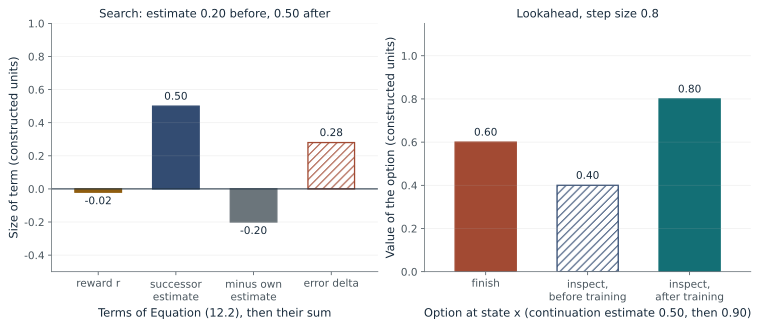

In [17]:
demo_id = 'C12-D04'
demo_controls = {'successor': 0.5, 'alpha': 0.8}
demo_result = run_demo(12, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Estimate after the search** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A positive error for a useless search, and a value that switches the action
Controls: {"successor": 0.1, "alpha": 0.8}
Evidence: constructed teaching example

Calculated quantities:
TD error delta: -0.12
Sign: negative
Successor estimate that gives zero: 0.22
Continuation estimate after training: 0.900
Inspect after training: 0.800
Action chosen after training: inspect

Worked steps:
1. Search error: delta = (-0.02) + 0.10 - 0.20 = -0.12 (negative).
2. Zero error at a successor estimate of 0.20 + 0.02 = 0.22.
3. Before training: inspect = (-0.1) + 0.5 = 0.4 against finish 0.6, so finish.
4. Training run reaches y and pays 1: delta = 1 + 0 - 0.5 = 0.5.
5. Update: 0.5 + 0.8 x 0.5 = 0.900.
6. After training: inspect = (-0.1) + 0.900 = 0.800 against finish 0.6: inspect.

delta = (-0.02) + 0.10 - 0.20 = -0.12. The error is zero at a successor estimate of 0.20 - (-0.02) = 0.22; above that it is positive, below it negative. The error is negative. The estimate fell from 0.20 to 0.10 after the 

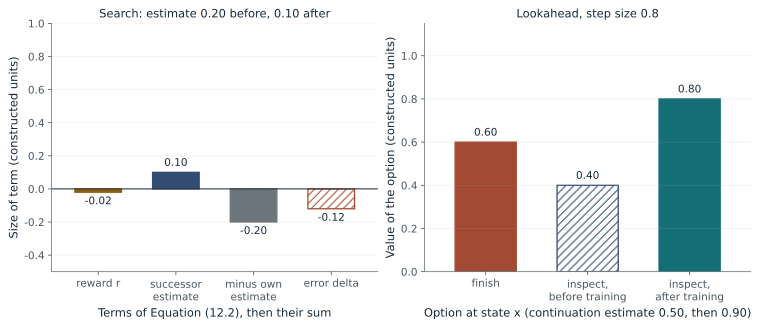

In [18]:
changed_controls = {'successor': 0.1, 'alpha': 0.8}
changed_demo = run_demo(12, 'C12-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(12, 'C12-D04'):
    state = run_demo(12, 'C12-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "successor": 0.1,
      "alpha": 0.3
    },
    "metrics": [
      [
        "TD error delta",
        "-0.12"
      ],
      [
        "Sign",
        "negative"
      ],
      [
        "Successor estimate that gives zero",
        "0.22"
      ],
      [
        "Continuation estimate after training",
        "0.650"
      ],
      [
        "Inspect after training",
        "0.550"
      ],
      [
        "Action chosen after training",
        "finish"
      ]
    ]
  },
  {
    "controls": {
      "successor": 0.1,
      "alpha": 0.4
    },
    "metrics": [
      [
        "TD error delta",
        "-0.12"
      ],
      [
        "Sign",
        "negative"
      ],
      [
        "Successor estimate that gives zero",
        "0.22"
      ],
      [
        "Continuation estimate after training",
        "0.700"
      ],
      [
        "Inspect after training",
        "0.600"
      ],
      [
        "Action chosen after training",
        "tie"


**Check your understanding:** At step size 0.5, what is the estimate of y after training, and which action does the controller now choose?

[Answer and worked reasoning](../solutions/ch12.md#demonstration-4). [Matching browser demonstration](../readers/12-trajectory-credit/reader.html#C12-D04).

## Questions

1. Compute default trace update to draft.

2. What are changed return targets?

3. What should lambda = 0 match?

Answers: [separate solutions](../solutions/ch12.md). Try the calculation before opening them.

## Summary

Credit rules differ in which future information they use. Monte Carlo follows the observed return, TD(0) bootstraps locally, and eligibility traces spread later errors through recent states. Terminal versus truncated boundaries alter continuation. The default is hand-checkable, the changed case exposes bootstrap dependence, and lambda zero checks the transfer identity. One finite update demonstrates mechanics, not convergence or reliable learning in a deployed agent.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-12-trajectory-credit`](../skills/maa-12-trajectory-credit/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 12.1

![Equation 12.1](../assets/math/d6697e3cc821de210964.svg)

Equation (12.1) drags each state's estimate toward the return that actually followed it.

Take the gap between what happened and what was predicted, keep a fraction of it, and add that to the prediction.

LaTeX source, preserved for inspection:

```latex
\hat V_{t+1}(x_t) \;=\; \hat V_t(x_t) \;+\; \alpha\big[\operatorname{Ret}_t - \hat V_t(x_t)\big].
\tag{12.1}
```

### Equation 12.2

![Equation 12.2](../assets/math/cc2c6da6e8a537b237b5.svg)

Equation (12.2) measures how much the agent's own opinion changed between one step and the next.

Compare what was predicted from here against the reward received plus what is predicted from there.

LaTeX source, preserved for inspection:

```latex
\delta_t \;=\; r_t \;+\; \gamma\,\hat V_t(x_{t+1}) \;-\; \hat V_t(x_t).
\tag{12.2}
```

### Equation 12.3

![Equation 12.3](../assets/math/bea157a42325799a5a1c.svg)

Equation (12.3) moves each estimate toward the estimate that came immediately after it.

Nudge the earlier prediction in the direction its own successor disagreed with it.

LaTeX source, preserved for inspection:

```latex
\hat V_{t+1}(x_t) \;=\; \hat V_t(x_t) \;+\; \alpha\,\delta_t.
\tag{12.3}
```

### Equation 12.4

![Equation 12.4](../assets/math/3def44a4bcac72579801.svg)

Equation (12.4) combines geometrically weighted intermediate targets with the remaining weight on the complete terminal return.

Weight intermediate lookahead targets geometrically, then place all remaining weight on the realized return through termination.

LaTeX source, preserved for inspection:

```latex
\operatorname{Ret}^{\lambda}_t \;=\; (1-\lambda)\sum_{k=1}^{N-t-1}\lambda^{\,k-1}\Big[\textstyle\sum_{j=0}^{k-1}\gamma^{\,j} r_{t+j} \;+\; \gamma^{\,k}\hat V_t(x_{t+k})\Big] \;+\; \lambda^{N-t-1}\operatorname{Ret}_t.
\tag{12.4}
```